# Third Assignment on Human Decision Making Under Uncertainty
>Panagiota Machaira <br />
>Undergraduate student <br />
>Department of Informatics <br />
>Athens University of Economics and Business <br />
>p3210119@aueb.gr

## General

This assignment investigates human decision-making under uncertainty using the [choices13k](https://github.com/jcpeterson/choices13k) dataset. 

The dataset was introduced by [Peterson et al. (2021)](https://www.science.org/doi/abs/10.1126/science.abe2629) and [Bourgin et al. (2019)](http://arxiv.org/abs/1905.09397) as part of their large-scale experimental studies on human decision-making and cognitive model priors. It consists of 13,006 distinct risky decision problems, each involving a choice between two gambles (Gamble A and Gamble B). Each decision problem was evaluated by multiple participants, allowing the estimation of aggregate choice behavior. 

The variable `bRate` denotes the fraction of participants who selected Gamble B for a given decision problem. The main objective of this assignment is to predict `bRate`, using at least three different machine learning methods and one neural network method. I evaluate the models mainly with $MAE$ (Mean Absolute Error), as it provides a direct interpretation of the average prediction error in the same units as `bRate`. Consequently, a lower $MAE$ indicates superior model performance. Apart from $MAE$ being the optimization target, I also report the $RMSE$ (Root Mean Square Error) and $R^2$ (R-squared) values for each model.

> The structure of the assignment follows the outline provided by Professor Panos Louridas, corresponding directly to the tasks specified in the assignment guidelines.

## Library imports and utilities

### Libraries

I import the libraries that are necessary for this project.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

import time
import joblib
import tempfile

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from sklearn.neural_network import MLPRegressor
from sklearn.kernel_approximation import Nystroem

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve

from xgboost import XGBRegressor

### Utilities

The foundation of this experimental control is a fixed random seed ($42$), which ensures that stochastic processes—such as data splitting, weight initialization, and hyperparameter sampling—remain consistent across all model iterations.

In [2]:
RANDOM_STATE = 42

For assessing model accuracy, I defined a standard Root Mean Squared Error (RMSE) function and a comprehensive evaluation utility, eval_on_split. This utility ensures a clean separation between training and testing by cloning the model architecture, fitting it exclusively on the training data, and then generating predictions on the held-out test set. It returns a dictionary of key performance indicators, including MAE, RMSE, and $R^2$, providing a multi-dimensional view of how well each model generalizes to unseen decision problems.

In [3]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def eval_on_split(model, X_train, y_train, X_test, y_test):
    """Fit once on train and evaluate on test."""
    m = clone(model)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    return {
        "MAE": float(mean_absolute_error(y_test, pred)),
        "RMSE": rmse(y_test, pred),
        "R2": float(r2_score(y_test, pred)),
        "model": m,
        "pred": pred,
    }

The core of the optimization process is the `run_search` function, which dynamically selects a tuning strategy based on the computational complexity of the model:
- Successive Halving (`HalvingRandomSearchCV`): Used for the computationally intensive models: Random Forest, XGBoost, and SVR. This method efficiently manages resources by using `n_estimators` as a "budget". It starts with many candidate parameter sets on a small amount of resources and progressively halves the pool, keeping only the best performers for the next, more resource-heavy iteration.
- Standard Randomized Search (`RandomizedSearchCV`): Employed for the MLP, using a multi-metric scoring approach to evaluate a fixed number of parameter samples.

In [4]:
def run_search(name, pipe, param_dist, X_train, y_train, cv, n_iter=20):
    """
    Fast tuning:
      - Expensive models (RF / SVR / XGB): HalvingRandomSearchCV
      - Others: RandomizedSearchCV
    """
    lname = str(name).lower()
    use_halving = any(k in lname for k in ["rf", "random forest", "svr", "xgb", "xgboost", "hgb", "hist"])

    if use_halving:
        scoring = "neg_mean_absolute_error"

        # If an __n_estimators param exists, use it as halving resource, but remove it from searched params
        resource = None
        param_dist2 = dict(param_dist)

        max_resources = "auto"
        min_resources = "smallest"

        for k in list(param_dist2.keys()):
            if k.endswith("__n_estimators"):
                resource = k
                try:
                    max_resources = int(max(param_dist2[k]))
                    min_resources = max(50, int(max_resources * 0.2))
                except Exception:
                    max_resources = "auto"
                    min_resources = "smallest"

                param_dist2.pop(k, None)
                break

        search = HalvingRandomSearchCV(
            pipe,
            param_distributions=param_dist2,
            scoring=scoring,
            refit=True,
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1,
            factor=3,
            resource=resource if resource is not None else "n_samples",
            max_resources=max_resources,
            min_resources=min_resources,
            n_candidates=n_iter,
        )

    else:
        scoring = {
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        }
        search = RandomizedSearchCV(
            pipe,
            param_distributions=param_dist,
            n_iter=n_iter,
            scoring=scoring,
            refit="mae",
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1,
        )

    t0 = time.perf_counter()
    search.fit(X_train, y_train)
    dt = time.perf_counter() - t0
    return search, dt

Because `HalvingRandomSearchCV` and standard `RandomizedSearchCV` store results differently across scikit-learn versions, I implemented `best_cv_metrics`. This function acts as a robust diagnostic tool; it either extracts the mean cross-validation scores directly from the search results or, in cases where the search object only tracked a single metric, triggers a full cross_validate re-computation. This ensures that the final model comparison is always based on a standardized calculation of `CV_MAE`, `CV_RMSE`, and `CV_R2`, allowing for an equal comparison of the models' stability.

In [5]:
def best_cv_metrics(search, X_train=None, y_train=None, cv=None):
    """
    Return CV metrics for the chosen best configuration.

    - If the search object supports multi-metric cv_results_ (RandomizedSearchCV), we read them directly.
    - If the search object is a Halving* search in an older scikit-learn that doesn't support dict scoring,
      we recompute (once) using cross_validate on search.best_estimator_.
    """
    res = getattr(search, "cv_results_", {}) or {}
    if ("mean_test_mae" in res) and ("mean_test_rmse" in res) and ("mean_test_r2" in res):
        i = search.best_index_
        return {
            "CV_MAE": float(-res["mean_test_mae"][i]),
            "CV_RMSE": float(-res["mean_test_rmse"][i]),
            "CV_R2": float(res["mean_test_r2"][i]),
        }

    if X_train is None or y_train is None or cv is None:
        raise ValueError("For halving searches, pass X_train, y_train, and cv into best_cv_metrics().")

    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    }
    scores = cross_validate(
        search.best_estimator_,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
    )
    return {
        "CV_MAE": float(-scores["test_mae"].mean()),
        "CV_RMSE": float(-scores["test_rmse"].mean()),
        "CV_R2": float(scores["test_r2"].mean()),
    }

## Data loading and feature building

The models utilized in this project rely exclusively on *numeric features* derived from task and option descriptions - such as payoffs, probabilities, ratios, and distributional summaries - because these metrics directly encode the quantitative structure of decision problems. By focusing on numeric data, the models can naturally express core decision-making theories like expected value and risk sensitivity while effectively capturing non-linear interactions. Based on my initial tests, these features provide the strongest predictive signal and result in the lowest Mean Absolute Error (MAE). In contrast, categorical variables and identifiers like trial IDs or condition names are intentionally excluded; their high cardinality causes them to function as noise rather than explanatory variables, leading to increased dimensionality. Preliminary experiments confirmed that including these identifiers worsened model performance, whereas their exclusion ensures the model prioritizes generalizable behavioral patterns over the simple memorization of specific trials.

To extract these numeric features, I combine the two files from choices13k:

- `c13k_selections.csv`: the main tabular dataset.  
  - Contains one row per decision trial.
  - Includes the target column `bRate` and other trial-level fields.

- `c13k_problems.json`: contains the full gamble definition for each row in the CSV.  
  - For each trial, it stores the two lotteries `A` and `B` as lists of outcomes and probabilities in the form `[[p, x], ...]`.
  - The JSON keys correspond to the row index of `c13k_selections.csv`.

The JSON uses the CSV row index as a key, so I create:

- `row_id` (string): generated by resetting the CSV index (`reset_index`) and converting it to a string.  
This guarantees that each CSV row can be matched to the correct JSON gamble definition.

In [6]:
sel = pd.read_csv("c13k_selections.csv")
assert "bRate" in sel.columns, "Target column bRate not found in c13k_selections.csv"

#create an explicit row_id that matches the JSON keys
sel = sel.reset_index(names="row_id")
sel["row_id"] = sel["row_id"].astype(str)

with open("c13k_problems.json", "r") as f:
    problems = json.load(f)
problems = {str(k): v for k, v in problems.items()}

For each trial, the JSON provides:
- `A`: list of (probability, outcome)
- `B`: list of (probability, outcome)

I use function `parse_gamble` to parse each gamble into:
- `x`: outcomes
- `p`: probabilities (renormalized to sum to 1 if needed)

In [7]:
def parse_gamble(gamble_obj):
    """
    gamble_obj: list of [probability, outcome]
    Returns:
        x : outcomes
        p : probabilities
    """
    arr = np.array(gamble_obj, dtype=float)
    p = arr[:, 0]
    x = arr[:, 1]
    if not np.isclose(p.sum(), 1.0):
        p = p / p.sum()
    return x, p

As mentioned above, the defined models work on numeric features so the raw list format must be converted into summary statistics.

For each gamble (A and B), I compute a set of numeric descriptors that summarize:
- central tendency,
- risk/dispersion,
- tail risk,
- and distribution complexity.

For each gamble I create the following columns (with prefixes described below):

*Core distribution statistics*
- `ev`: expected value (mean payoff)
- `var`: variance
- `std`: standard deviation (risk/dispersion)
- `skew`: skewness (asymmetry of outcomes)

*Support and range*
- `min`: worst outcome
- `max`: best outcome
- `range`: max − min

*Salient probabilities*
- `p_gain`: probability of a positive outcome (x > 0)
- `p_loss`: probability of a negative outcome (x < 0)
- `p_zero`: probability of a zero outcome (x == 0)
- `p_maxmass`: largest single outcome probability (max p)

*Complexity / concentration*
- `entropy`: Shannon entropy of the distribution (spread/uncertainty)
- `herfindahl`: concentration index (sum of $p^2$); higher means more concentrated
- `eff_n`: effective number of outcomes ($\approx$ 1 / herfindahl)
- `n_outcomes`: number of distinct outcomes in the gamble

*Downside risk / tail behavior*
- `semivar`: semi-variance below the expected value (downside risk)
- `q10`: 10th percentile outcome (lower tail threshold)
- `q05`: 5th percentile outcome (more extreme lower tail)
- `es10`: expected shortfall at 10% (average payoff in the worst 10%)

*Scale-normalized risk*
- `cv`: coefficient of variation = $\frac{std}{\left|ev\right|}$ (risk relative to reward)

I construct these features because they encode meaningful decision-theoretic and behavioral properties (value, risk, tail losses, complexity), which are known to influence human choices under uncertainty and therefore should help predict `bRate`.

In [8]:
def gamble_moments(x, p):
    """Compute distribution statistics + tail/shape features."""
    p = np.array(p, dtype=float)
    p = p / p.sum()
    x = np.array(x, dtype=float)

    ev = float(np.sum(p * x))
    var = float(np.sum(p * (x - ev) ** 2))
    std = float(np.sqrt(var))

    if std > 1e-12:
        skew = float(np.sum(p * ((x - ev) / std) ** 3))
    else:
        skew = 0.0

    xmin = float(np.min(x))
    xmax = float(np.max(x))
    rng = float(xmax - xmin)

    #salient probabilities
    p_gain = float(np.sum(p[x > 0]))
    p_loss = float(np.sum(p[x < 0]))
    p_zero = float(np.sum(p[x == 0]))
    p_maxmass = float(np.max(p))

    #distribution concentration / complexity
    eps = 1e-12
    entropy = float(-(p * np.log(p + eps)).sum())
    herfindahl = float((p ** 2).sum()) #concentration
    eff_n = float(1.0 / (herfindahl + eps)) #effective number of outcomes

    #downside risk (semi-variance below EV)
    downside = np.minimum(0.0, x - ev)
    semivar = float(np.sum(p * (downside ** 2)))

    #discrete quantiles and expected shortfall
    order = np.argsort(x)
    xs = x[order]
    ps = p[order]
    cdf = np.cumsum(ps)

    def q_at(alpha: float) -> float:
        idx = int(np.searchsorted(cdf, alpha, side="left"))
        idx = min(max(idx, 0), len(xs) - 1)
        return float(xs[idx])

    q10 = q_at(0.10)
    q05 = q_at(0.05)

    #expected shortfall at 10%: E[X | X <= q10]
    mask = xs <= q10 + 1e-12
    tail_p = float(ps[mask].sum())
    if tail_p > eps:
        es10 = float((ps[mask] * xs[mask]).sum() / tail_p)
    else:
        es10 = q10

    cv = float(std / (abs(ev) + 1e-9))

    return {
        "ev": ev,
        "var": var,
        "std": std,
        "skew": skew,
        "min": xmin,
        "max": xmax,
        "range": rng,
        "p_gain": p_gain,
        "p_loss": p_loss,
        "p_zero": p_zero,
        "p_maxmass": p_maxmass,
        "entropy": entropy,
        "herfindahl": herfindahl,
        "eff_n": eff_n,
        "semivar": semivar,
        "q10": q10,
        "q05": q05,
        "es10": es10,
        "cv": cv,
        "n_outcomes": float(len(x)),
    }

Using the `gamble_moments` function described above, I store all gamble moments features twice:

- `A_*` columns: statistics of gamble A (e.g., `A_ev`, `A_std`, `A_p_loss`, $\ldots$)  
- `B_*` columns: statistics of gamble B (e.g., `B_ev`, `B_std`, `B_p_loss`, $\ldots$)

because the decision is between two options, so we need descriptors for both.

Human decisions are often driven by comparisons rather than absolute values, so I define function `build_features_for_row` to explicitly construct:

*Differences: `D_* = B_* − A_*`*
For every moment feature `k`, I create:
- `D_k = B_k − A_k` 
Example: `D_ev`, `D_std`, `D_p_loss`, etc.

This captures how much better/worse B is than A on value, risk, tail loss, etc.

*Stabilized ratios*
- `ratio_ev` = (B_ev + $\epsilon$) / (A_ev + $\epsilon$)
- `ratio_std` = (B_std + $\epsilon$) / (A_std + $\epsilon$)

Ratios capture relative advantage and stabilization prevents division-by-zero issues.

*Extra comparison features*
- `abs_D_ev`: absolute difference in expected value
- `abs_D_std`: absolute difference in risk
- `D_ev_over_sumstd = D_ev / (A_std + B_std + ε)`

These capture magnitude of differences and a simple "signal-to-risk" style comparison.

*Dominance indicators (min/max)*
- `A_dominates_B_minmax` = 1 if A.min $\geq$ B.min AND A.max $\geq$ B.max else 0
- `B_dominates_A_minmax` = 1 if B.min $\geq$ A.min AND B.max $\geq$ A.max else 0

Dominance relations are highly predictive in decision making; if one option dominates, behavior becomes more consistent.

In [9]:
def build_features_for_row(prob_obj):
    """prob_obj: {'A': [[p,x],...], 'B': [[p,x],...]}"""
    Ax, Ap = parse_gamble(prob_obj["A"])
    Bx, Bp = parse_gamble(prob_obj["B"])

    A = gamble_moments(Ax, Ap)
    B = gamble_moments(Bx, Bp)

    feats = {}
    for k, v in A.items():
        feats[f"A_{k}"] = v
    for k, v in B.items():
        feats[f"B_{k}"] = v

    #differences (B − A)
    for k in A.keys():
        feats[f"D_{k}"] = B[k] - A[k]

    #ratios (stabilized)
    feats["ratio_ev"] = (B["ev"] + 1e-9) / (A["ev"] + 1e-9)
    feats["ratio_std"] = (B["std"] + 1e-9) / (A["std"] + 1e-9)

    #extra comparison features (often predictive)
    feats["abs_D_ev"] = abs(feats["D_ev"])
    feats["abs_D_std"] = abs(feats["D_std"])
    feats["D_ev_over_sumstd"] = feats["D_ev"] / (A["std"] + B["std"] + 1e-9)

    #simple dominance indicators (min/max)
    feats["A_dominates_B_minmax"] = int((A["min"] >= B["min"]) and (A["max"] >= B["max"]))
    feats["B_dominates_A_minmax"] = int((B["min"] >= A["min"]) and (B["max"] >= A["max"]))

    return feats

I build a derived feature table (`feat_df`) aligned by `row_id` and merge into the selection table:

- `data = sel.merge(feat_df, on="row_id", how="left")`

This produces one modeling row per trial, containing:
- original CSV fields (including `bRate`)
- all derived gamble summary features (`A_*`, `B_*`, `D_*`, ratios, dominance flags)

Finally, I convert boolean columns to integers (0/1) so they can be used as numeric features.

This ensures the final dataset is suitable for regression modeling.

In [10]:
#build derived features aligned to CSV row_id
rows = []
missing = 0
for rid in sel["row_id"].values:
    if rid in problems:
        feats = build_features_for_row(problems[rid])
        feats["row_id"] = rid
        rows.append(feats)
    else:
        missing += 1
        rows.append({"row_id": rid})

feat_df = pd.DataFrame(rows)

data = sel.merge(feat_df, on="row_id", how="left")

#normalize boolean-like columns to numeric so they are usable features
for col in data.columns:
    if data[col].dtype == bool:
        data[col] = data[col].astype(int)

for col in ["feedback", "Amb"]:
    if col in data.columns and data[col].dtype == object:
        data[col] = data[col].astype(str).str.lower().map({"true": 1, "false": 0, "1": 1, "0": 0}).fillna(data[col])
        # if still non-numeric, leave as-is (will be dropped by numeric-only selection)

print("Rows:", len(data), "Missing JSON rows:", missing)
print("Derived feature columns added:", feat_df.shape[1] - 1)
data.head()

Rows: 14568 Missing JSON rows: 0
Derived feature columns added: 67


,row_id,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,...,D_es10,D_cv,D_n_outcomes,ratio_ev,ratio_std,abs_D_ev,abs_D_std,D_ev_over_sumstd,A_dominates_B_minmax,B_dominates_A_minmax
0,0,1,1,15,2,26,0.95,-1,23,0.05,...,-3.65,-0.218064,0.0,0.855984,7.407407e-02,3.55,5.448624,-0.561673,0,0
1,1,2,1,15,4,14,0.60,-18,8,0.25,...,13.00,-9.847280,0.0,-1.458333,3.590777e-01,2.95,10.047569,-0.138459,0,0
2,2,3,1,17,4,2,0.50,0,1,1.00,...,1.00,-1.000000,-1.0,1.000000,1.000000e-09,0.00,1.000000,0.000000,0,0
3,3,4,1,18,3,37,0.05,8,87,0.25,...,-39.00,33.395248,1.0,-0.158730,8.084311e+00,10.95,44.775707,-0.190712,0,0
4,4,5,0,15,1,26,1.00,26,45,0.75,...,-62.00,1.441970,4.0,0.951923,3.568876e+10,1.25,35.688759,-0.035025,0,0


## Split of training / test data and preprocessing

The dataset is then split into training and test sets using an 80/20 split, with the fixed random seed mentioned earlier to ensure reproducibility. The training set is used for model fitting and hyperparameter tuning, while the test set is held out for final performance evaluation.

For model validation during tuning, 3-fold cross-validation is employed. Compared to 5-fold cross-validation, this choice significantly reduces computational cost while still providing a reliable estimate of model performance.

A common preprocessing pipeline is applied to all numeric features. Missing values are imputed using the median, which is robust to outliers, and features are subsequently standardized using z-score normalization (StandardScaler). This preprocessing ensures that all numeric variables are on a comparable scale and suitable for algorithms that are sensitive to feature magnitudes.

In [11]:
target = "bRate"
y = data[target].astype(float)

# drop target (and keep only numeric features)
X = data.drop(columns=[target])
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X_num = X[numeric_cols].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=RANDOM_STATE
)

# 3-fold CV
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# numeric preprocessor:
num_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


## Method 1 — XGBoost (gradient boosting)

I create a **XGBoost** regression pipeline that integrates a numerical preprocessing stage with an XGBRegressor using the histogram-based tree method. To achieve the lowest possible Mean Absolute Error $(MAE)$, I implemented an expanded hyperparameter search using a wide distribution of settings. This search specifically targets structural parameters—including tree depth and learning rates—alongside a multi-layered sampling strategy involving subsampling and column sampling at the tree, level, and node stages. To ensure the objective function is optimized for the task, the code dynamically selects the most appropriate MAE-friendly objectives, such as `reg:absoluteerror` or `reg:pseudohubererror`. Robustness is further enforced through a comprehensive regularization suite ($L1$, $L2$, and gamma pruning) and a successive halving approach using n_estimators as the budget. The final model is selected based on the best cross-validation performance and is then verified against a hold-out test split to report the final $MAE$, $RMSE$, and $R^2$ metrics.

In [12]:
#Model 1: XGBoost regression + hyperparameter search

print("Starting XGB search...")

from packaging import version
import xgboost as xgb
from xgboost import XGBRegressor

#prefer MAE-friendly objectives when available
if version.parse(xgb.__version__) >= version.parse("1.6.0"):
    xgb_objectives = ["reg:absoluteerror", "reg:pseudohubererror", "reg:squarederror"]
else:
    xgb_objectives = ["reg:squarederror"]

xgb_pipe = Pipeline(steps=[
    ("prep", num_preprocess),
    ("model", XGBRegressor(
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        verbosity=0,
    ))
])

#wide search with successive halving
#n_estimators is used as the halving budget
xgb_param_dist = {
    "model__n_estimators": [300, 600, 1000], #budget levels
    "model__objective": xgb_objectives,

    #core structure
    "model__max_depth": [2, 3, 4, 5, 6, 7, 8],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15],

    #sampling
    "model__subsample": [0.55, 0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.55, 0.7, 0.85, 1.0],
    "model__colsample_bylevel": [0.7, 0.85, 1.0],
    "model__colsample_bynode": [0.7, 0.85, 1.0],

    #regularization & robustness
    "model__min_child_weight": [1, 2, 3, 5, 7, 10],
    "model__gamma": [0.0, 0.1, 0.3, 0.7, 1.5],
    "model__reg_alpha": [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 5e-2],
    "model__reg_lambda": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    "model__max_delta_step": [0, 1, 5],
}

xgb_search, xgb_seconds = run_search(
    "XGB",
    xgb_pipe,
    xgb_param_dist,
    X_train,
    y_train,
    cv=cv,
    n_iter=60
)

xgb_best = xgb_search.best_estimator_
print("XGB best params:", xgb_search.best_params_)

xgb_cv = best_cv_metrics(xgb_search, X_train, y_train, cv)
print("XGB CV:", xgb_cv, "| seconds:", round(xgb_seconds, 2))

xgb_test = eval_on_split(xgb_best, X_train, y_train, X_test, y_test)
print("XGB TEST:", {k: xgb_test[k] for k in ["MAE", "RMSE", "R2"]})

Starting XGB search...
n_iterations: 2
n_required_iterations: 4
n_possible_iterations: 2
min_resources_: 200
max_resources_: 1000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 60
n_resources: 200
Fitting 3 folds for each of 60 candidates, totalling 180 fits
----------
iter: 1
n_candidates: 20
n_resources: 600
Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGB best params: {'model__subsample': 0.85, 'model__reg_lambda': 2.0, 'model__reg_alpha': 1e-06, 'model__objective': 'reg:squarederror', 'model__min_child_weight': 5, 'model__max_depth': 7, 'model__max_delta_step': 0, 'model__learning_rate': 0.03, 'model__gamma': 0.0, 'model__colsample_bytree': 0.85, 'model__colsample_bynode': 0.85, 'model__colsample_bylevel': 0.7, 'model__n_estimators': 600}
XGB CV: {'CV_MAE': 0.06450103452565152, 'CV_RMSE': 0.0852978675712056, 'CV_R2': 0.8522675359589492} | seconds: 122.39
XGB TEST: {'MAE': 0.062129219749593456, 'RMSE': 0.08377744000380617, 'R2': 0.8566369916

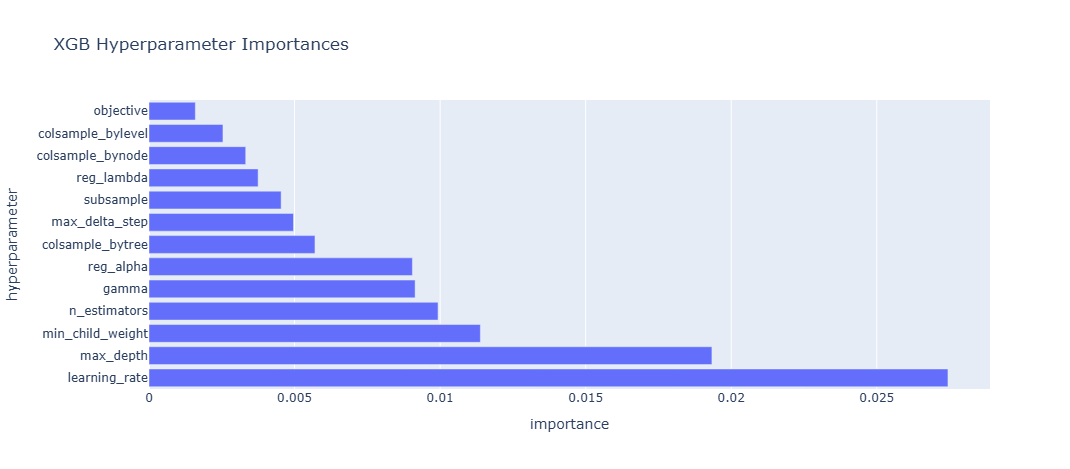

In [13]:
# collect tried parameter sets + their CV score
cvres = pd.DataFrame(xgb_search.cv_results_)

scores = cvres["mean_test_score"].copy()

param_cols = [c for c in cvres.columns if c.startswith("param_")]
importances = []
for c in param_cols:
    s = cvres[[c]].copy()
    s["score"] = scores.values
    # group by param value, take mean score per value, then take range
    imp = s.groupby(c, dropna=False)["score"].mean().max() - s.groupby(c, dropna=False)["score"].mean().min()
    importances.append((c.replace("param_model__", ""), float(imp)))

imp_df = pd.DataFrame(importances, columns=["hyperparameter", "importance"]).sort_values("importance")

fig = px.bar(
    imp_df, x="importance", y="hyperparameter", orientation="h",
    title="XGB Hyperparameter Importances"
)
fig.update_layout(width=1100, height=450, yaxis=dict(autorange="reversed"))
fig.show()

## Method 2 — Random Forest

My second model utilizes a **Random Forest** regression pipeline. This pipeline begins with a specific preprocessing step that employs a SimpleImputer with a median strategy to ensure data completeness before the regression stage. To optimize performance, I conduct a hyperparameter search focused on controlling tree complexity and feature diversity. This includes tuning the max_depth up to 28 levels, adjusting the `min_samples_split` and `min_samples_leaf` to manage node granularity, and testing varying `max_features` ratios—ranging from the square root of features to 90% of the feature space—to find the ideal balance of ensemble diversity. The search strategy utilizes successive halving, treating `n_estimators` as the primary resource budget to efficiently narrow down the most promising configurations. To further prevent overfitting, the search includes `ccp_alpha` for Cost-Complexity Pruning. After identifying the best-performing estimator via cross-validation, the model is evaluated on the hold-out test split, focusing again on $MAE$, $RMSE$, and $R^2$.

In [14]:
#Model 2: Random Forest regression + hyperparameter search

print("Starting RF search...")

rf_pipe = Pipeline(steps=[
    ("prep", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        bootstrap=True,
        max_samples=0.7   # <-- speedup: fewer rows per tree
    ))
])

rf_param_dist = {
    "model__n_estimators": [60, 100, 150],
    "model__max_depth": [None, 12, 20],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7],
    "model__ccp_alpha": [0.0, 1e-4, 1e-3],
    "model__bootstrap": [True],
}

rf_search, rf_seconds = run_search(
    "RF",
    rf_pipe,
    rf_param_dist,
    X_train,
    y_train,
    cv=cv,
    n_iter=10 
)

rf_best = rf_search.best_estimator_
print("RF best params:", rf_search.best_params_)

rf_cv = best_cv_metrics(rf_search, X_train, y_train, cv)
print("RF CV:", rf_cv, "| seconds:", round(rf_seconds, 2))

# refit once with more trees (outside CV, cheap)
rf_best.set_params(model__n_estimators=600, model__max_samples=0.8)
rf_best.fit(X_train, y_train)

rf_test = eval_on_split(rf_best, X_train, y_train, X_test, y_test)
print("RF TEST:", {k: rf_test[k] for k in ["MAE","RMSE","R2"]})

Starting RF search...
n_iterations: 2
n_required_iterations: 3
n_possible_iterations: 2
min_resources_: 50
max_resources_: 150
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 10
n_resources: 50
Fitting 3 folds for each of 10 candidates, totalling 30 fits
----------
iter: 1
n_candidates: 4
n_resources: 150
Fitting 3 folds for each of 4 candidates, totalling 12 fits
RF best params: {'model__min_samples_leaf': 4, 'model__max_features': 0.7, 'model__max_depth': 20, 'model__ccp_alpha': 0.0, 'model__bootstrap': True, 'model__n_estimators': 150}
RF CV: {'CV_MAE': 0.06853575665336017, 'CV_RMSE': 0.09117890842052913, 'CV_R2': 0.8311808997578677} | seconds: 54.37
RF TEST: {'MAE': 0.06661441956013987, 'RMSE': 0.0894113002437661, 'R2': 0.8367069292722309}


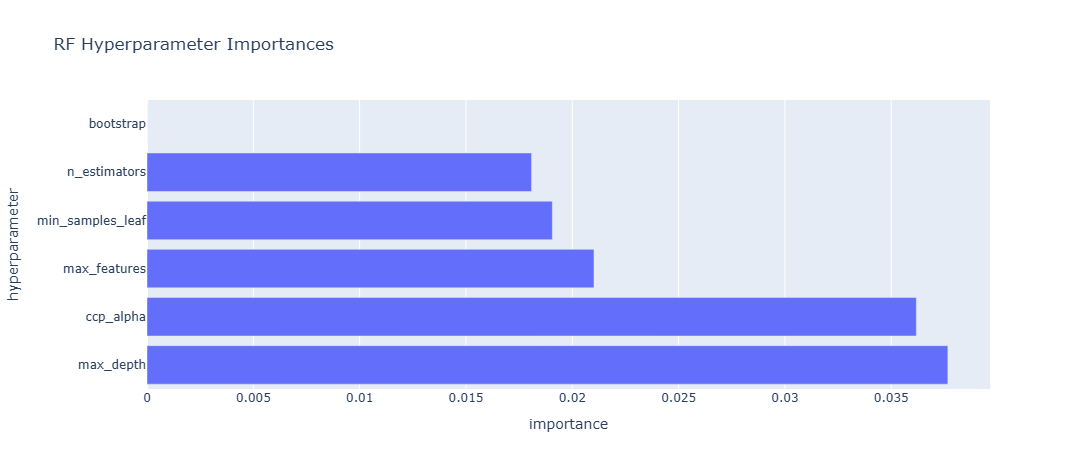

In [15]:
# collect tried parameter sets + their CV score
cvres = pd.DataFrame(rf_search.cv_results_)

scores = cvres["mean_test_score"].copy()

param_cols = [c for c in cvres.columns if c.startswith("param_")]
importances = []
for c in param_cols:
    s = cvres[[c]].copy()
    s["score"] = scores.values
    # group by param value, take mean score per value, then take range
    imp = s.groupby(c, dropna=False)["score"].mean().max() - s.groupby(c, dropna=False)["score"].mean().min()
    importances.append((c.replace("param_model__", ""), float(imp)))

imp_df = pd.DataFrame(importances, columns=["hyperparameter", "importance"]).sort_values("importance")

fig = px.bar(
    imp_df, x="importance", y="hyperparameter", orientation="h",
    title="RF Hyperparameter Importances"
)
fig.update_layout(width=1100, height=450, yaxis=dict(autorange="reversed"))
fig.show()

## Method 3 — Support Vector Regression (RBF approximation)

My third model utilizes a **Support Vector Regression** (SVR) approximation strategy, designed to capture non-linear relationships with greater computational efficiency. The pipeline pairs the numeric preprocessor with a Nystroem transformer, which uses a subset of the data to approximate a Radial Basis Function (RBF) kernel, followed by a LinearSVR head. To optimize this approximation, I conduct a hyperparameter search across the number of components and the RBF kernel’s gamma parameter, while simultaneously tuning the regression-specific variables: the `regularization parameter C` and the `epsilon margin`, which defines the threshold where errors are ignored. To manage the overhead of these kernel transformations during the search, I implemented a caching mechanism using joblib. This memory stores intermediate feature states in a temporary directory to accelerate the iterative process. The model is configured with a high iteration limit and an automated dual solver selection to ensure convergence. Like the previous models, the optimal configuration is identified through cross-validation and finally benchmarked on the test split using $MAE$, $RMSE$, and $R^2$.

In [16]:
#Model 3: SVR approximation (Nystroem + LinearSVR) + hyperparameter search

print("Starting RBF-SVR approximation search (cached Nystroem + LinearSVR)...")

memory = joblib.Memory(location=tempfile.mkdtemp(), verbose=0)

svr_approx_pipe = Pipeline(
    steps=[
        ("prep", num_preprocess),
        ("feat", Nystroem(random_state=RANDOM_STATE)),
        ("model", LinearSVR(
            random_state=RANDOM_STATE,
            dual="auto",
            max_iter=20000,
            tol=1e-3
        ))
    ],
    memory=memory
)

svr_param_dist = {
    "feat__n_components": [200, 300, 500],
    "feat__gamma": np.logspace(-3, -1, 6),
    "model__C": np.logspace(-1, 2, 8),
    "model__epsilon": [0.01, 0.05, 0.1],
}

svr_search, svr_seconds = run_search(
    "SVR_approx",
    svr_approx_pipe,
    svr_param_dist,
    X_train,
    y_train,
    cv=cv,
    n_iter=12
)

svr_best = svr_search.best_estimator_
print("SVR approx best params:", svr_search.best_params_)
svr_cv = best_cv_metrics(svr_search, X_train, y_train, cv)
print("SVR approx CV:", svr_cv, "| seconds:", round(svr_seconds, 2))

svr_test = eval_on_split(svr_best, X_train, y_train, X_test, y_test)
print("SVR approx TEST:", {k: svr_test[k] for k in ["MAE","RMSE","R2"]})

Starting RBF-SVR approximation search (cached Nystroem + LinearSVR)...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 7
min_resources_: 6
max_resources_: 11654
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 12
n_resources: 6
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 1
n_candidates: 4
n_resources: 18
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 2
n_candidates: 2
n_resources: 54
Fitting 3 folds for each of 2 candidates, totalling 6 fits
SVR approx best params: {'model__epsilon': 0.01, 'model__C': np.float64(1.9306977288832496), 'feat__n_components': 200, 'feat__gamma': np.float64(0.00630957344480193)}
SVR approx CV: {'CV_MAE': 0.0871262727032653, 'CV_RMSE': 0.11169056334167597, 'CV_R2': 0.7466726846042312} | seconds: 3.52
SVR approx TEST: {'MAE': 0.08645758402153535, 'RMSE': 0.11093810264316263, 'R2': 0.7486120810509047}


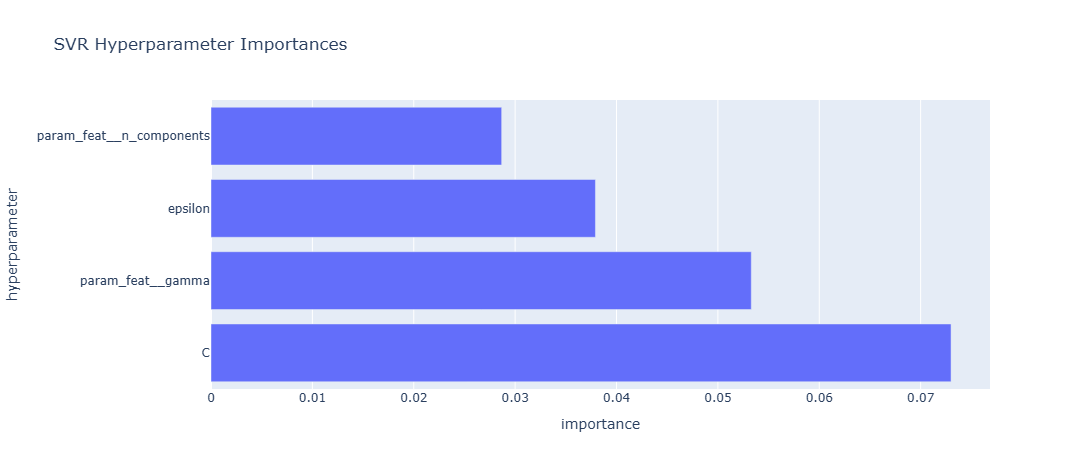

In [17]:
# collect tried parameter sets + their CV score
cvres = pd.DataFrame(svr_search.cv_results_)

scores = cvres["mean_test_score"].copy()

param_cols = [c for c in cvres.columns if c.startswith("param_")]
importances = []
for c in param_cols:
    s = cvres[[c]].copy()
    s["score"] = scores.values
    # group by param value, take mean score per value, then take range
    imp = s.groupby(c, dropna=False)["score"].mean().max() - s.groupby(c, dropna=False)["score"].mean().min()
    importances.append((c.replace("param_model__", ""), float(imp)))

imp_df = pd.DataFrame(importances, columns=["hyperparameter", "importance"]).sort_values("importance")

fig = px.bar(
    imp_df, x="importance", y="hyperparameter", orientation="h",
    title="SVR Hyperparameter Importances"
)
fig.update_layout(width=1100, height=450, yaxis=dict(autorange="reversed"))
fig.show()

## Method 4 — Neural Network (MLP)

The fourth model is a **Multi-Layer Perceptron** (MLP) regressor, representing a neural network approach to the decision-task data. The pipeline feeds the numeric features into a flexible architecture where I test both shallow and deeper configurations, specifically evaluating single layers of 64 or 128 neurons alongside a bottlenecked dual-layer structure $(128, 64)$. To optimize the training dynamics, the hyperparameter search tunes the initial learning rate and batch size, while also exploring different non-linearities through the relu and tanh activation functions. To ensure the model generalizes well and avoids overfitting, I implemented early stopping. This mechanism monitors a validation fraction of 15% of the data and halts training if no improvement is observed for 10 consecutive iterations. Additionally, the search includes an $L2$ regularization term (alpha) across a logarithmic scale to penalize excessive weight magnitudes. As with the previous models, the best estimator is selected via cross-validation and its final performance is reported using $MAE$, $RMSE$, and $R^2$ on the hold-out test set.

In [18]:
#Model 4: MLP regression + hyperparameter search

print("Starting MLP search...")

mlp_pipe = Pipeline(steps=[
    ("prep", num_preprocess),
    ("model", MLPRegressor(
        random_state=RANDOM_STATE,
        max_iter=1200,
        early_stopping=True,
        n_iter_no_change=20,
        validation_fraction=0.15
    ))
])

mlp_param_dist = {
    "model__hidden_layer_sizes": [(64,), (128,), (128, 64)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": np.logspace(-6, -4, 6),
    "model__learning_rate_init": np.logspace(-4, -2, 6),
    "model__batch_size": [128, 256],
}

mlp_search, mlp_seconds = run_search(
    "MLP",
    mlp_pipe,
    mlp_param_dist,
    X_train,
    y_train,
    cv=cv,
    n_iter=40
)

mlp_best = mlp_search.best_estimator_
print("MLP best params:", mlp_search.best_params_)
mlp_cv = best_cv_metrics(mlp_search, X_train, y_train, cv)
print("MLP CV:", mlp_cv, "| seconds:", round(mlp_seconds, 2))

mlp_test = eval_on_split(mlp_best, X_train, y_train, X_test, y_test)
print("MLP TEST:", {k: mlp_test[k] for k in ["MAE","RMSE","R2"]})

Starting MLP search...
Fitting 3 folds for each of 40 candidates, totalling 120 fits
MLP best params: {'model__learning_rate_init': np.float64(0.01), 'model__hidden_layer_sizes': (64,), 'model__batch_size': 128, 'model__alpha': np.float64(6.30957344480193e-06), 'model__activation': 'relu'}
MLP CV: {'CV_MAE': 0.07378200361668025, 'CV_RMSE': 0.09537270345782171, 'CV_R2': 0.8151974351901967} | seconds: 159.5
MLP TEST: {'MAE': 0.07237612678888758, 'RMSE': 0.09418580894922582, 'R2': 0.8188017999036665}


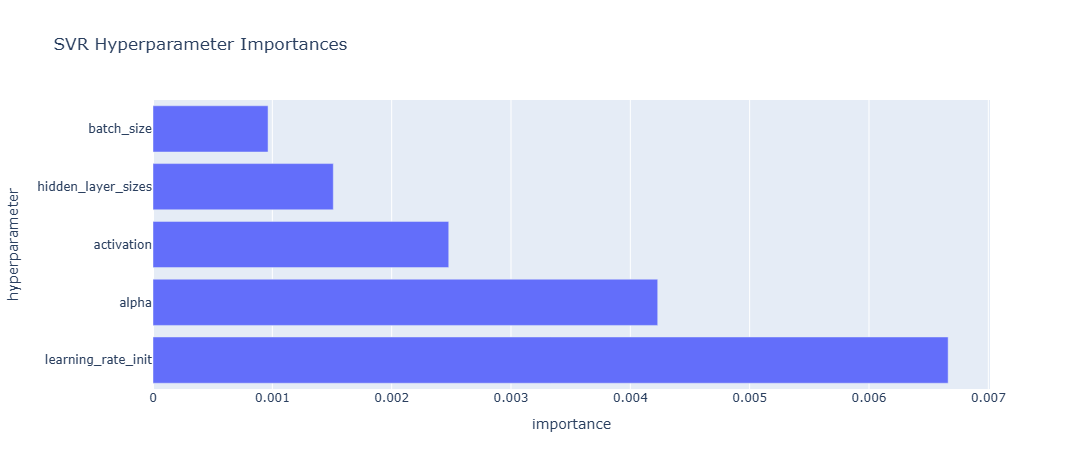

In [19]:
# collect tried parameter sets + their CV score
cvres = pd.DataFrame(mlp_search.cv_results_)

scores = -cvres["mean_test_mae"].astype(float).copy()

param_cols = [c for c in cvres.columns if c.startswith("param_")]
importances = []
for c in param_cols:
    s = cvres[[c]].copy()
    s["score"] = scores.values
    # group by param value, take mean score per value, then take range
    imp = s.groupby(c, dropna=False)["score"].mean().max() - s.groupby(c, dropna=False)["score"].mean().min()
    importances.append((c.replace("param_model__", ""), float(imp)))

imp_df = pd.DataFrame(importances, columns=["hyperparameter", "importance"]).sort_values("importance")

fig = px.bar(
    imp_df, x="importance", y="hyperparameter", orientation="h",
    title="SVR Hyperparameter Importances"
)
fig.update_layout(width=1100, height=450, yaxis=dict(autorange="reversed"))
fig.show()

## Best Method

To conclude the analysis, I aggregate the performance of all four candidates into a comparative `summary` table, sorting them by their cross-validation $MAE$. I use cross-validation as the primary selection criterion to ensure the chosen model is picked based on stable development performance rather than luck, while the test metrics serve as a final unbiased verification. Once the top-performing architecture is identified I perform a diagnostic feature importance analysis to understand the underlying behavioral drivers.

In [20]:
#Compare models
summary = pd.DataFrame([
    {"Model": "XGB", **xgb_cv, "Test_MAE": xgb_test["MAE"], "Test_RMSE": xgb_test["RMSE"], "Test_R2": xgb_test["R2"], "Seconds": xgb_seconds},
    {"Model": "RF",  **rf_cv,  "Test_MAE": rf_test["MAE"],  "Test_RMSE": rf_test["RMSE"],  "Test_R2": rf_test["R2"],  "Seconds": rf_seconds},
    {"Model": "SVR_approx", **svr_cv, "Test_MAE": svr_test["MAE"], "Test_RMSE": svr_test["RMSE"], "Test_R2": svr_test["R2"], "Seconds": svr_seconds},
    {"Model": "MLP", **mlp_cv, "Test_MAE": mlp_test["MAE"], "Test_RMSE": mlp_test["RMSE"], "Test_R2": mlp_test["R2"], "Seconds": mlp_seconds},
]).sort_values("CV_MAE")

display(summary)

best_row = summary.iloc[0]
best_name = best_row["Model"]
print("Best by CV MAE:", best_name)

best_model = {
    "XGB": xgb_best,
    "RF": rf_best,
    "SVR_approx": svr_best,
    "MLP": mlp_best,
}[best_name]

,Model,CV_MAE,CV_RMSE,CV_R2,Test_MAE,Test_RMSE,Test_R2,Seconds
0,XGB,0.064501,0.085298,0.852268,0.062129,0.083777,0.856637,122.390015
1,RF,0.068536,0.091179,0.831181,0.066614,0.089411,0.836707,54.372479
3,MLP,0.073782,0.095373,0.815197,0.072376,0.094186,0.818802,159.500633
2,SVR_approx,0.087126,0.111691,0.746673,0.086458,0.110938,0.748612,3.519525


Best by CV MAE: XGB


I extract the built-in feature importance scores to assess how often specific numeric attributes were used to partition the data. If a non-tree model is selected as the winner, I instead utilize permutation importance on the test set, which involves shuffling individual features to measure their specific impact on prediction error. This diagnostic step ensures that the model’s "black box" decisions remain interpretable, allowing me to verify that the most predictive features align with the quantitative structure of the decision problems.

In [21]:
# Feature importance: for tree models use built-in; otherwise use permutation importance (fast settings).
if best_name in ["XGB", "RF"]:
    model_step = best_model.named_steps["model"]
    importances = model_step.feature_importances_
    imp = pd.DataFrame({"feature": numeric_cols, "importance": importances}).sort_values("importance", ascending=False)
    display(imp.head(25))
else:
    r = permutation_importance(
        best_model, X_test, y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    imp = pd.DataFrame({"feature": numeric_cols, "importance": r.importances_mean}).sort_values("importance", ascending=False)
    display(imp.head(25))

,feature,importance
81,B_dominates_A_minmax,0.257136
80,A_dominates_B_minmax,0.143334
79,D_ev_over_sumstd,0.131761
55,D_ev,0.052690
63,D_p_loss,0.041819
62,D_p_gain,0.040966
72,D_es10,0.028670
14,bRate_std,0.023377
12,Amb,0.017932
60,D_max,0.012621


### Performance summary
- **XGBoost (XGB)** achieved the lowest $CV$ $MAE$ **$(0.064501)$** and the lowest $test$ $MAE$ **$(0.062129)$**, indicating strong generalization.
- Random Forest performed reasonably well but was consistently worse and slower than XGB.
- MLP and SVR showed higher error and weaker generalization.

So we select XGB as the final model.

### Overfitting check

To assess whether the selected model suffers from overfitting, I plot learning curves showing training and cross-validated mean absolute error (MAE) as a function of training set size. This allows us to evaluate how model performance and the generalization gap evolve as more data become available.

I define a function to make the overfitting learning curves plot.

In [22]:
def plot_overfitting_learning_curve(model, X, y, cv, title="Learning Curve Mean Absolute Error"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring="neg_mean_absolute_error",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    train_mae = -train_scores.mean(axis=1)
    val_mae = -val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(7, 4), dpi=120)

    ax.plot(train_sizes, train_mae, marker="o", label="Train MAE")
    ax.plot(train_sizes, val_mae, marker="o", label="CV MAE")

    ax.fill_between(train_sizes, train_mae - (-train_std), train_mae + (-train_std), alpha=0.15)
    ax.fill_between(train_sizes, val_mae - (-val_std), val_mae + (-val_std), alpha=0.15)

    ax.set_xlabel("Training set size")
    ax.set_ylabel("MAE")
    ax.set_title(title)
    ax.legend()

    plt.tight_layout()
    plt.show()

I apply the plotting function to the XGB MAE results.

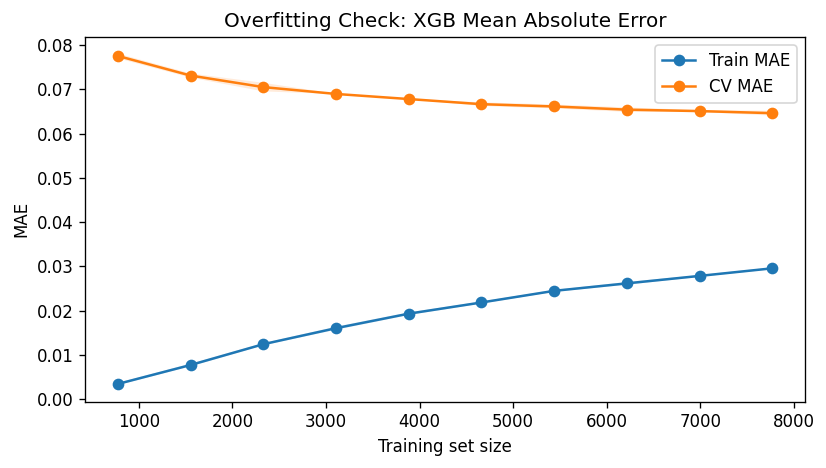

In [23]:
plot_overfitting_learning_curve(best_model, X_train, y_train, cv, title=f"Overfitting Check: {best_name} Mean Absolute Error")

The plot shows a clear gap between training and cross-validated $MAE$, indicating that the model fits the training data much better than unseen data. However, this gap stabilizes as training size increases, and the cross-validated $MAE$ closely matches the held-out test MAE, suggesting that the observed gap does not worsen with additional data. Based on these checks, there is no evidence of increasing overfitting, although the remaining gap likely reflects model capacity and noise in the target rather than perfect generalization.

### Interpretation of the most important features

After selecting XGBoost as the final model, feature importance was analyzed using the model’s built-in tree-based importance scores. Each feature's importance score reflects predictive contribution. The 10 features with the highest importance are shown in the following table.

In [24]:
display(imp.head(10))

,feature,importance
81,B_dominates_A_minmax,0.257136
80,A_dominates_B_minmax,0.143334
79,D_ev_over_sumstd,0.131761
55,D_ev,0.052690
63,D_p_loss,0.041819
62,D_p_gain,0.040966
72,D_es10,0.028670
14,bRate_std,0.023377
12,Amb,0.017932
60,D_max,0.012621


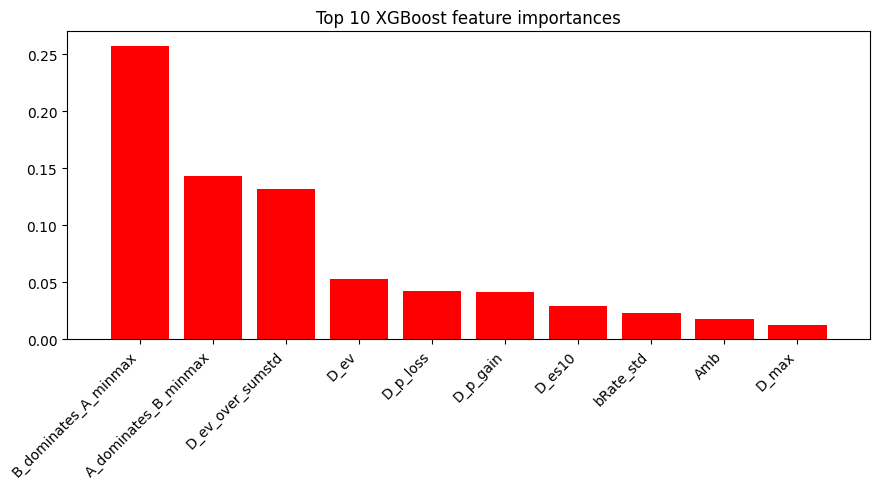

In [25]:
# Select top 10 features
top_n = 10
imp_top = imp.head(top_n)

# Values for plotting
features = imp_top["feature"].values
importances = imp_top["importance"].values

std = np.zeros_like(importances)

# Plot
plt.figure(figsize=(9, 5))
plt.title("Top 10 XGBoost feature importances")
plt.bar(
    range(top_n),
    importances,
    yerr=std,
    color="r",
    align="center"
)
plt.xticks(range(top_n), features, rotation=45, ha="right")
plt.xlim([-1, top_n])
plt.tight_layout()
plt.show()


The most influential features identified by the XGBoost model can be grouped into
three broad behavioral categories. Together, these features explain how comparative
structure, value–risk trade-offs, and gain–loss asymmetries shape variation in
`bRate`.

1. *Dominance and comparative structure*

   The most important features overall are `B_dominates_A_minmax` and `A_dominates_B_minmax`, which indicate whether one option strictly dominates the other in terms of both minimum and maximum outcomes. Their high importance shows that human decision-making is strongly guided by clear dominance relations. When one option dominates another, the choice problem becomes simpler and behavior more consistent, leading to more predictable behavioral rates. The prominence of these features suggests that participants rely heavily on straightforward comparative cues when they are available.

2. *Expected value, dispersion, and downside risk*

   Several highly ranked features capture differences in average payoff and risk, including `D_ev`, `D_ev_over_sumstd`, `D_max`, and `D_es10`. These features reflect not only how much better one option is on average, but also how that advantage compares to overall variability and lower-tail outcomes. Their importance indicates that participants evaluate options using risk-adjusted value rather than expected value alone. Differences in downside risk and extreme outcomes play a meaningful role in shaping behavior, particularly when payoffs are uncertain.

3. *Gain–loss asymmetry and sensitivity to uncertainty*

   Features such as `D_p_gain`, `D_p_loss`, and `Amb` capture asymmetries in the probability of gains versus losses and the presence of ambiguity. The importance of these features is consistent with well-established findings in behavioral economics: losses tend to exert a stronger influence on decisions than gains of the same magnitude. The probability of negative outcomes therefore has a disproportionate impact on `bRate`, while ambiguity further affects behavior beyond simple risk considerations.

Overall, the feature importance analysis shows that `bRate` is driven primarily by
comparative structure and risk-adjusted differences between options, rather than
by absolute payoff levels alone. This pattern closely aligns with theoretical
accounts of human decision-making under uncertainty.


## Final predictions for `bRate`

This final block presents the predictions produced by the best-performing model - `XGBoost` - and summarizes how well these predictions match the observed behavioral rates.

Using the XGBoost model predictions are generated for the `held-out test set`.
For each test observation, the following are reported:
- the true observed value of `bRate`,
- the predicted value of `bRate`,
- the absolute prediction error.

A preview of individual predictions is shown to illustrate typical prediction accuracy at the level of single trials.

In [26]:
print("Final model selected (by CV MAE):", best_name)

#predict bRate for the test split
y_pred_final = best_model.predict(X_test)

#build a DataFrame of true vs predicted bRate and compute absolute error
pred_df = pd.DataFrame({
    "bRate_true": np.asarray(y_test),
    "bRate_pred": np.asarray(y_pred_final),
})
pred_df["abs_error"] = np.abs(pred_df["bRate_true"] - pred_df["bRate_pred"])

#show a quick preview of predictions
display(pred_df.head(15))

Final model selected (by CV MAE): XGB


,bRate_true,bRate_pred,abs_error
0,0.387500,0.553904,0.166404
1,0.700000,0.625298,0.074702
2,0.550000,0.517523,0.032477
3,0.670588,0.698035,0.027446
4,0.612500,0.680024,0.067524
5,0.040000,0.035402,0.004598
6,0.480000,0.478122,0.001878
7,0.764706,0.818948,0.054242
8,0.466667,0.521007,0.054341
9,0.613333,0.731226,0.117892


The distributions of true and predicted `bRate` values are shown in the plot below.

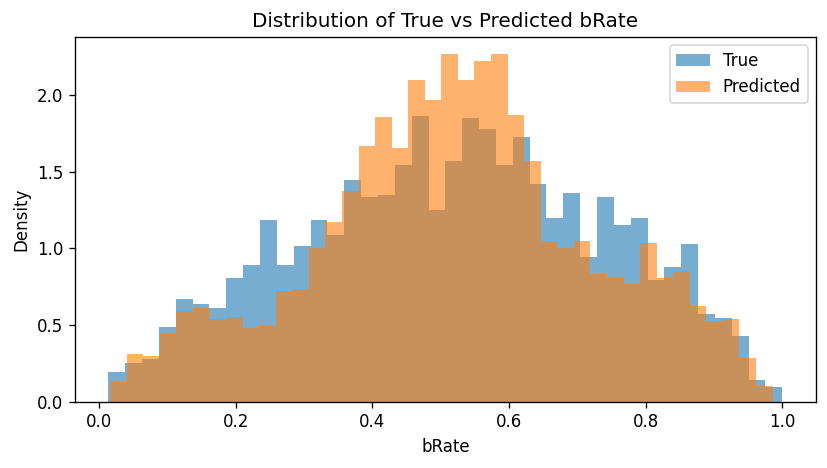

In [27]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)

ax.hist(pred_df["bRate_true"], bins=40, alpha=0.6, label="True", density=True)
ax.hist(pred_df["bRate_pred"], bins=40, alpha=0.6, label="Predicted", density=True)

ax.set_xlabel("bRate")
ax.set_ylabel("Density")
ax.set_title("Distribution of True vs Predicted bRate")
ax.legend()

plt.tight_layout()
plt.show()

The two distributions largely overlap, indicating that the model captures the overall range and shape of the target variable well. Differences are more pronounced in the central range, suggesting mild smoothing of predictions around the mean rather than distortion at the boundaries.

Summary statistics of the test-set predictions are reported for:
- `bRate_true`: the distribution of observed behavioral rates,
- `bRate_pred`: the distribution of predicted behavioral rates,
- `abs_error`: the distribution of absolute prediction errors.

In [28]:
#summaries for the final prediction of bRate
print("\nPrediction summary (hold-out test):")
display(pred_df[["bRate_true", "bRate_pred", "abs_error"]].describe().T)


Prediction summary (hold-out test):


,count,mean,std,min,25%,50%,75%,max
bRate_true,2914.0,0.518250,0.221301,0.013333,0.356140,0.525000,0.687500,1.000000
bRate_pred,2914.0,0.520066,0.203323,0.015905,0.392628,0.521771,0.645758,0.985716
abs_error,2914.0,0.062129,0.056211,0.000017,0.020482,0.046831,0.086768,0.561558


The prediction summary on the held-out test set shows that the model’s predicted `bRate` closely matches the true distribution. The predicted mean ($\approx$ 0.52) is nearly identical to the true mean, and the median prediction aligns closely with the observed median. The spread of predicted values is slightly narrower than the true distribution, indicating mild smoothing but no systematic bias. Absolute errors are generally small, with a median error of about 0.047 and 75% of errors below approximately 0.087, suggesting that most predictions are close to the true behavioral rates of `bRate`.

Below is a binned calibration plot comparing mean predicted and true `bRate` values.

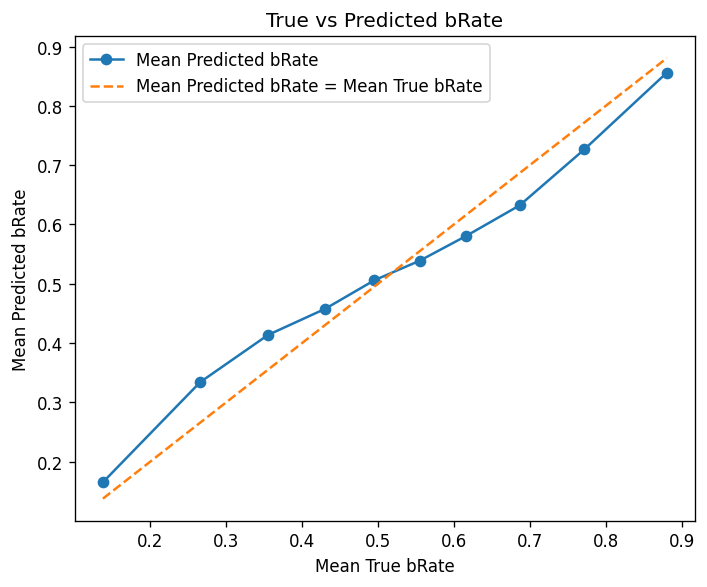

In [29]:
df = pred_df.copy()

# bin by true bRate
df["bRate_bin"] = pd.qcut(df["bRate_true"], q=10, duplicates="drop")

bin_stats = df.groupby("bRate_bin", observed=True).agg(
    true_mean=("bRate_true", "mean"),
    pred_mean=("bRate_pred", "mean"),
    count=("bRate_true", "size")
).reset_index()

fig, ax = plt.subplots(figsize=(6, 5), dpi=120)

ax.plot(
    bin_stats["true_mean"],
    bin_stats["pred_mean"],
    marker="o",
    label="Mean Predicted bRate"
)

ax.plot(
    [bin_stats["true_mean"].min(), bin_stats["true_mean"].max()],
    [bin_stats["true_mean"].min(), bin_stats["true_mean"].max()],
    linestyle="--",
    label="Mean Predicted bRate = Mean True bRate"
)

ax.set_xlabel("Mean True bRate")
ax.set_ylabel("Mean Predicted bRate")
ax.set_title("True vs Predicted bRate")

ax.legend()

plt.tight_layout()
plt.show()


>The dashed line indicates perfect calibration (y=x) where mean predicted would equal mean true of bRate.

A shown in the plot, the predicted `bRate` closely follows the ideal `y = x` line, indicating good overall calibration. Small deviations at lower and higher `bRate` values suggest mild under- and over-prediction in those regions, but the relationship remains approximately linear, indicating that the model captures the main structure of the target well.

Finally, two error measures are reported:
- **Test MAE**: computed on the held-out test set, providing an estimate of out-of-sample prediction accuracy.
- **Cross-validated MAE**: reported from the cross-validation results and used as the official performance metric, as required.

In [30]:
#test MAE
final_test_mae = float(mean_absolute_error(pred_df["bRate_true"], pred_df["bRate_pred"]))
print("\nFinal model TEST MAE:", final_test_mae)

#cross-validated MAE
final_cv_mae = float(summary.loc[summary["Model"] == best_name, "CV_MAE"].iloc[0])
print("Final model Cross-Validated MAE (CV):", final_cv_mae)


Final model TEST MAE: 0.062129219749593456
Final model Cross-Validated MAE (CV): 0.06450103452565152


The similarity between `CV MAE` and `test MAE` suggests good generalization and limited overfitting.

## Conclusion

This project demonstrates that `bRate` can be predicted with good accuracy using a structured representation of gamble characteristics. Among the evaluated models, `XGBoost` achieved the strongest predictive performance, with closely matched cross-validated and test-set `MAE`, indicating stable generalization.

Model performance is driven primarily by features capturing comparative structure and risk-related properties, such as dominance relationships, expected value differences, outcome variability, and gain-loss asymmetries. These features align with established theories of decision-making under uncertainty, which emphasize relative evaluation and risk sensitivity.

Cross-validated and test-set MAE are very similar, indicating that model performance is consistent across data splits. The learning curve shows a stable gap between training and validation error that does not increase with additional data. Together, these results suggest that the model generalizes reliably and does not exhibit problematic overfitting.

>**Final model:** XGBoost  
**Cross-validated MAE:** $0.06450103452565152$